<a href="https://colab.research.google.com/github/BenChiesa/ECGR_4105/blob/Assignments/Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error

df = pd.read_csv('/content/Housing.csv')

Problem 1

<ipython-input-24-ecdba4bd3b46>:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[binary_columns] = df[binary_columns].applymap(lambda x: 1 if x == "yes" else 0)


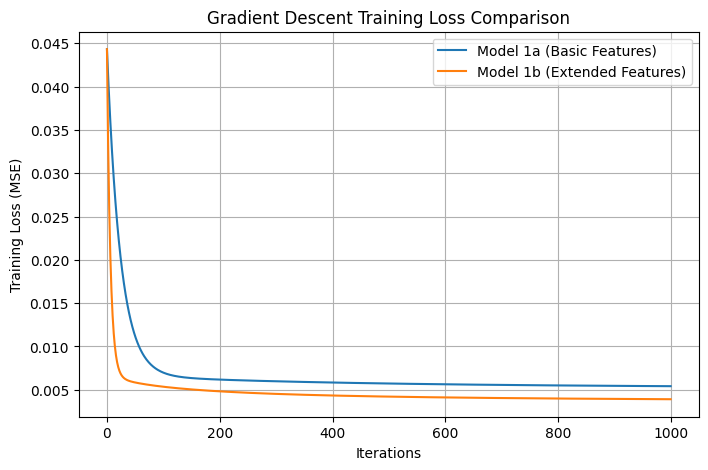

Validation Loss (Model 1a): 0.017490717474913358
Validation Loss (Model 1b): 0.013419975798626858


In [24]:
binary_columns = ["mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "prefarea"]
df[binary_columns] = df[binary_columns].applymap(lambda x: 1 if x == "yes" else 0)

df = pd.get_dummies(df, columns=["furnishingstatus"], drop_first=True)

features_a = ["area", "bedrooms", "bathrooms", "stories", "parking"]
features_b = ["area", "bedrooms", "bathrooms", "stories", "mainroad", "guestroom", "basement",
              "hotwaterheating", "airconditioning", "parking", "prefarea"]

scaler = MinMaxScaler()
df[features_a + features_b] = scaler.fit_transform(df[features_a + features_b])

target = "price"
df[target] = scaler.fit_transform(df[[target]])

train_data, val_data = train_test_split(df, test_size=0.2, random_state=42)
X_train_a, y_train_a = train_data[features_a].values, train_data[target].values
X_val_a, y_val_a = val_data[features_a].values, val_data[target].values
X_train_b, y_train_b = train_data[features_b].values, train_data[target].values
X_val_b, y_val_b = val_data[features_b].values, val_data[target].values

def gradient_descent(X, y, learning_rate=0.05, iterations=1000):
    m, n = X.shape
    theta = np.zeros(n)
    losses = []

    for i in range(iterations):
        predictions = X @ theta
        errors = predictions - y
        gradient = (1/m) * (X.T @ errors)
        theta -= learning_rate * gradient
        mse = (1/(2*m)) * np.sum(errors**2)
        losses.append(mse)

    return theta, losses

learning_rate = 0.05
iterations = 1000
theta_a, loss_a = gradient_descent(X_train_a, y_train_a, learning_rate, iterations)
theta_b, loss_b = gradient_descent(X_train_b, y_train_b, learning_rate, iterations)

plt.figure(figsize=(8, 5))
plt.plot(range(iterations), loss_a, label="Model 1a (Basic Features)")
plt.plot(range(iterations), loss_b, label="Model 1b (Extended Features)")
plt.xlabel("Iterations")
plt.ylabel("Training Loss (MSE)")
plt.title("Gradient Descent Training Loss Comparison")
plt.legend()
plt.grid()
plt.show()

def evaluate_model(X, y, theta):
    predictions = X @ theta
    mse = mean_squared_error(y, predictions)
    return mse

val_loss_a = evaluate_model(X_val_a, y_val_a, theta_a)
val_loss_b = evaluate_model(X_val_b, y_val_b, theta_b)

print("Validation Loss (Model 1a):", val_loss_a)
print("Validation Loss (Model 1b):", val_loss_b)

Problem 2

<ipython-input-22-f0499caf489f>:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[binary_columns] = df[binary_columns].applymap(lambda x: 1 if x == "yes" else 0)


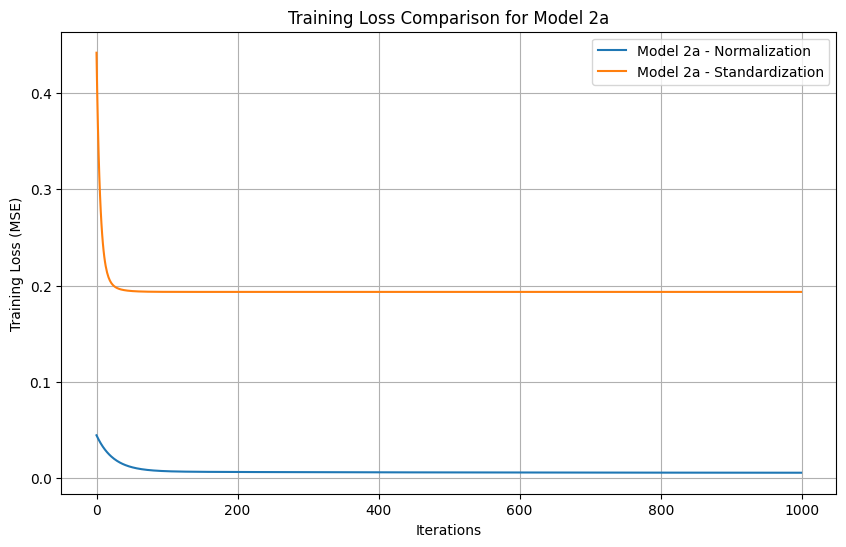

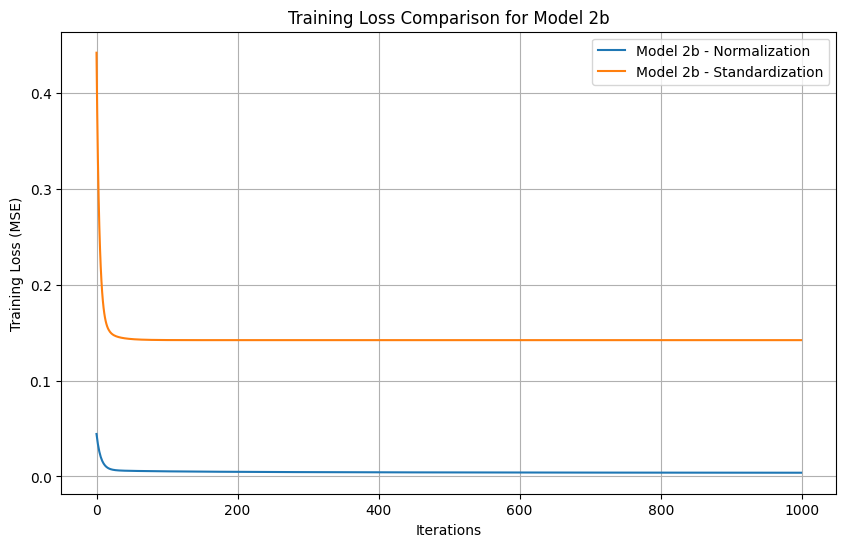

Validation Loss (Model 2a - Normalization): 0.017490717474913355
Validation Loss (Model 2a - Standardization): 0.6552421878178809
Validation Loss (Model 2b - Normalization): 0.013419975798626858
Validation Loss (Model 2b - Standardization): 0.5140729713678117


In [22]:
binary_columns = ["mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "prefarea"]
df[binary_columns] = df[binary_columns].applymap(lambda x: 1 if x == "yes" else 0)

df = pd.get_dummies(df, columns=["furnishingstatus"], drop_first=True)

features_a = ["area", "bedrooms", "bathrooms", "stories", "parking"]
features_b = ["area", "bedrooms", "bathrooms", "stories", "mainroad", "guestroom", "basement",
              "hotwaterheating", "airconditioning", "parking", "prefarea"]

target = "price"

def scale_data(df, features, method="normalization"):
    scaler = MinMaxScaler() if method == "normalization" else StandardScaler()
    scaled_features = scaler.fit_transform(df[features])
    scaled_target = scaler.fit_transform(df[[target]])
    return scaled_features, scaled_target.flatten()

X_norm_a, y_norm_a = scale_data(df, features_a, method="normalization")
X_norm_b, y_norm_b = scale_data(df, features_b, method="normalization")

X_std_a, y_std_a = scale_data(df, features_a, method="standardization")
X_std_b, y_std_b = scale_data(df, features_b, method="standardization")

def split_data(X, y):
    return train_test_split(X, y, test_size=0.2, random_state=42)

X_train_norm_a, X_val_norm_a, y_train_norm_a, y_val_norm_a = split_data(X_norm_a, y_norm_a)
X_train_norm_b, X_val_norm_b, y_train_norm_b, y_val_norm_b = split_data(X_norm_b, y_norm_b)
X_train_std_a, X_val_std_a, y_train_std_a, y_val_std_a = split_data(X_std_a, y_std_a)
X_train_std_b, X_val_std_b, y_train_std_b, y_val_std_b = split_data(X_std_b, y_std_b)

def gradient_descent(X, y, learning_rate=0.05, iterations=1000):
    m, n = X.shape
    theta = np.zeros(n)
    losses = []

    for i in range(iterations):
        predictions = X @ theta
        errors = predictions - y
        gradient = (1/m) * (X.T @ errors)
        theta -= learning_rate * gradient
        mse = (1/(2*m)) * np.sum(errors**2)
        losses.append(mse)

    return theta, losses

learning_rate = 0.05
iterations = 1000
theta_norm_a, loss_norm_a = gradient_descent(X_train_norm_a, y_train_norm_a, learning_rate, iterations)
theta_norm_b, loss_norm_b = gradient_descent(X_train_norm_b, y_train_norm_b, learning_rate, iterations)
theta_std_a, loss_std_a = gradient_descent(X_train_std_a, y_train_std_a, learning_rate, iterations)
theta_std_b, loss_std_b = gradient_descent(X_train_std_b, y_train_std_b, learning_rate, iterations)

plt.figure(figsize=(10, 6))
plt.plot(range(iterations), loss_norm_a, label="Model 2a - Normalization")
plt.plot(range(iterations), loss_std_a, label="Model 2a - Standardization")
plt.xlabel("Iterations")
plt.ylabel("Training Loss (MSE)")
plt.title("Training Loss Comparison for Model 2a")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(range(iterations), loss_norm_b, label="Model 2b - Normalization")
plt.plot(range(iterations), loss_std_b, label="Model 2b - Standardization")
plt.xlabel("Iterations")
plt.ylabel("Training Loss (MSE)")
plt.title("Training Loss Comparison for Model 2b")
plt.legend()
plt.grid()
plt.show()

def evaluate_model(X, y, theta):
    predictions = X @ theta
    mse = mean_squared_error(y, predictions)
    return mse

val_loss_norm_a = evaluate_model(X_val_norm_a, y_val_norm_a, theta_norm_a)
val_loss_norm_b = evaluate_model(X_val_norm_b, y_val_norm_b, theta_norm_b)
val_loss_std_a = evaluate_model(X_val_std_a, y_val_std_a, theta_std_a)
val_loss_std_b = evaluate_model(X_val_std_b, y_val_std_b, theta_std_b)

print("Validation Loss (Model 2a - Normalization):", val_loss_norm_a)
print("Validation Loss (Model 2a - Standardization):", val_loss_std_a)
print("Validation Loss (Model 2b - Normalization):", val_loss_norm_b)
print("Validation Loss (Model 2b - Standardization):", val_loss_std_b)

Problem 3

<ipython-input-27-74ef633d43c3>:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[binary_columns] = df[binary_columns].applymap(lambda x: 1 if x == "yes" else 0)


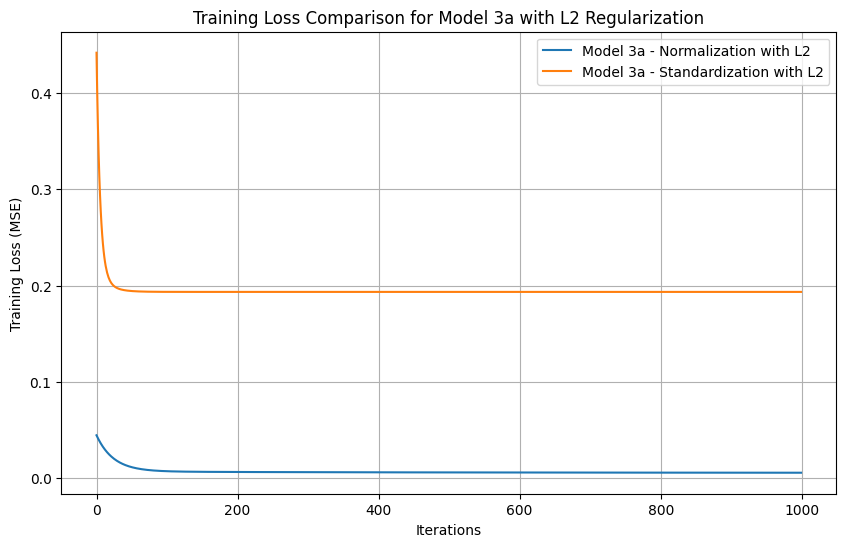

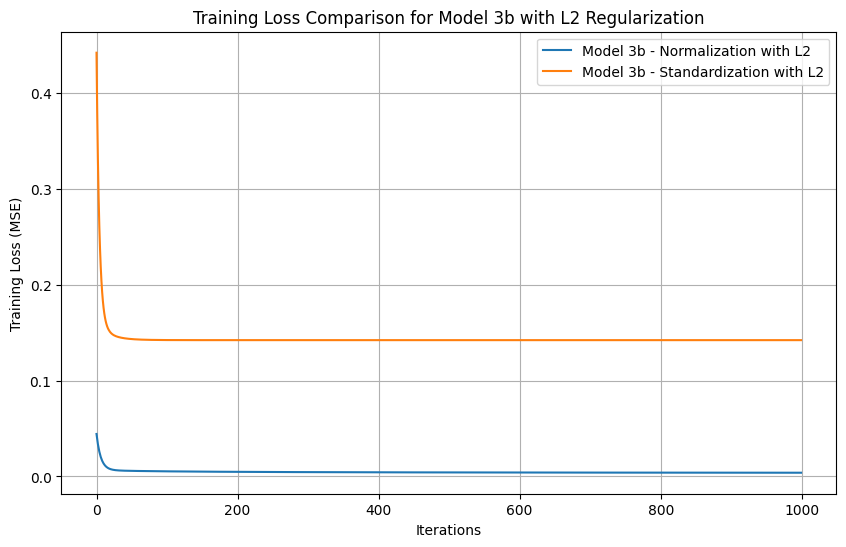

Validation Loss (Model 3a - Normalization with L2): 0.017504459244497256
Validation Loss (Model 3a - Standardization with L2): 0.6552727137621394
Validation Loss (Model 3b - Normalization with L2): 0.013430842893109295
Validation Loss (Model 3b - Standardization with L2): 0.5140866649117969


In [27]:
binary_columns = ["mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "prefarea"]
df[binary_columns] = df[binary_columns].applymap(lambda x: 1 if x == "yes" else 0)

df = pd.get_dummies(df, columns=["furnishingstatus"], drop_first=True)

features_a = ["area", "bedrooms", "bathrooms", "stories", "parking"]
features_b = ["area", "bedrooms", "bathrooms", "stories", "mainroad", "guestroom", "basement",
              "hotwaterheating", "airconditioning", "parking", "prefarea"]

target = "price"

def scale_data(df, features, method="normalization"):
    scaler = MinMaxScaler() if method == "normalization" else StandardScaler()
    scaled_features = scaler.fit_transform(df[features])
    scaled_target = scaler.fit_transform(df[[target]])
    return scaled_features, scaled_target.flatten()

X_norm_a, y_norm_a = scale_data(df, features_a, method="normalization")
X_norm_b, y_norm_b = scale_data(df, features_b, method="normalization")

X_std_a, y_std_a = scale_data(df, features_a, method="standardization")
X_std_b, y_std_b = scale_data(df, features_b, method="standardization")

def split_data(X, y):
    return train_test_split(X, y, test_size=0.2, random_state=42)

X_train_norm_a, X_val_norm_a, y_train_norm_a, y_val_norm_a = split_data(X_norm_a, y_norm_a)
X_train_norm_b, X_val_norm_b, y_train_norm_b, y_val_norm_b = split_data(X_norm_b, y_norm_b)
X_train_std_a, X_val_std_a, y_train_std_a, y_val_std_a = split_data(X_std_a, y_std_a)
X_train_std_b, X_val_std_b, y_train_std_b, y_val_std_b = split_data(X_std_b, y_std_b)

def gradient_descent_l2(X, y, learning_rate=0.05, iterations=1000, lambda_reg=0.1):
    m, n = X.shape
    theta = np.zeros(n)
    losses = []

    for i in range(iterations):
        predictions = X @ theta
        errors = predictions - y
        gradient = (1/m) * (X.T @ errors) + (lambda_reg/m) * theta
        theta -= learning_rate * gradient
        mse = (1/(2*m)) * np.sum(errors**2)
        losses.append(mse)

    return theta, losses

learning_rate = 0.05
iterations = 1000
lambda_reg = 0.1
theta_norm_a, loss_norm_a = gradient_descent_l2(X_train_norm_a, y_train_norm_a, learning_rate, iterations, lambda_reg)
theta_norm_b, loss_norm_b = gradient_descent_l2(X_train_norm_b, y_train_norm_b, learning_rate, iterations, lambda_reg)
theta_std_a, loss_std_a = gradient_descent_l2(X_train_std_a, y_train_std_a, learning_rate, iterations, lambda_reg)
theta_std_b, loss_std_b = gradient_descent_l2(X_train_std_b, y_train_std_b, learning_rate, iterations, lambda_reg)

plt.figure(figsize=(10, 6))
plt.plot(range(iterations), loss_norm_a, label="Model 3a - Normalization with L2")
plt.plot(range(iterations), loss_std_a, label="Model 3a - Standardization with L2")
plt.xlabel("Iterations")
plt.ylabel("Training Loss (MSE)")
plt.title("Training Loss Comparison for Model 3a with L2 Regularization")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(range(iterations), loss_norm_b, label="Model 3b - Normalization with L2")
plt.plot(range(iterations), loss_std_b, label="Model 3b - Standardization with L2")
plt.xlabel("Iterations")
plt.ylabel("Training Loss (MSE)")
plt.title("Training Loss Comparison for Model 3b with L2 Regularization")
plt.legend()
plt.grid()
plt.show()

def evaluate_model(X, y, theta):
    predictions = X @ theta
    mse = mean_squared_error(y, predictions)
    return mse

val_loss_norm_a = evaluate_model(X_val_norm_a, y_val_norm_a, theta_norm_a)
val_loss_norm_b = evaluate_model(X_val_norm_b, y_val_norm_b, theta_norm_b)
val_loss_std_a = evaluate_model(X_val_std_a, y_val_std_a, theta_std_a)
val_loss_std_b = evaluate_model(X_val_std_b, y_val_std_b, theta_std_b)

print("Validation Loss (Model 3a - Normalization with L2):", val_loss_norm_a)
print("Validation Loss (Model 3a - Standardization with L2):", val_loss_std_a)
print("Validation Loss (Model 3b - Normalization with L2):", val_loss_norm_b)
print("Validation Loss (Model 3b - Standardization with L2):", val_loss_std_b)
